# Date-range sensitivity — window vs full

For every behavioural indicator and behavioural anchor, we run the ON-vs-OFF
Mann-Whitney U test **twice**: once on the **full** experimental window
(everything labelled ON or OFF), and once on a **user-restricted** window
(`DATE_START`, `DATE_END` in the config cell below). The two results sit side
by side in one table so you can directly read off whether trimming the window
changed the effect — which is how we probed whether the active\_hours signal
was driven by the late-May heatwave.

**Conditions.** The same `label_date` used in `multi_day_pipeline_v3` is
applied here: 5/26 is `EXCLUDED` (Narda calibration day), 5/29 is overridden
to `OFF`, everything before `CYCLE_ANCHOR = 2026-04-23` is `BASELINE`. With
the 5/26 exclusion + 5/29 OFF override the full experimental window contains
**18 ON and 18 OFF day-system rows per system** (six ON blocks and six OFF
blocks of three days each).

**Indicators.** The six pre-registered FII indicators plus the two
behavioural anchors that survived methodological scrutiny (`peak_hour`,
`active_hours`). `first_exit_hour` is omitted — greenhouse gates open at a
fixed time so it carries no information.

**Significance and effect-size legend.**

| symbol | $p$-value | reading |
|---|---|---|
| `***` | $p < 0.001$ | highly significant |
| `**`  | $0.001 \le p < 0.01$ | very significant |
| `*`   | $0.01 \le p < 0.05$ | significant |
| `+`   | $0.05 \le p < 0.10$ | marginal / trend |
| `ns`  | $p \ge 0.10$ | not significant |

| label | $\lvert r \rvert$ | reading |
|---|---|---|
| `large` | $\ge 0.5$ | large effect (Cohen) |
| `med`   | $0.3 \le \lvert r \rvert < 0.5$ | **medium effect — pre-registered "directional" flag** |
| `small` | $0.1 \le \lvert r \rvert < 0.3$ | small effect |
| `neg`   | $< 0.1$ | negligible |


In [12]:
# ─── imports, load, condition labels ───
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
from math import erf, sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data/multi_day_v3")
ind = pd.read_csv(DATA / "indicators_daily.csv")
ptk = pd.read_csv(DATA / "per_track_indicators.csv", parse_dates=["ts"])

CYCLE_ANCHOR   = pd.Timestamp("2026-04-23")
EXCLUDED_DATES = {pd.Timestamp("2026-05-26")}      # Narda calibration

def label_date(d):
    d = pd.Timestamp(d)
    if d in EXCLUDED_DATES: return "EXCLUDED"
    #if d in OFF_OVERRIDE:   return "OFF"
    if d < CYCLE_ANCHOR:    return "BASELINE"
    return "ON" if ((d - CYCLE_ANCHOR).days // 3) % 2 == 0 else "OFF"

ind["date_ts"]   = pd.to_datetime(ind["date"])
ind["condition"] = ind["date_ts"].apply(label_date)
ptk["date_ts"]   = pd.to_datetime(ptk["date"])
ptk["hour"]      = ptk["ts"].dt.hour
print(f"Loaded {len(ind)} day-system indicator rows and {len(ptk):,} per-track rows.")
print(f"Full date range in indicators_daily: {ind['date'].min()} -> {ind['date'].max()}")


Loaded 82 day-system indicator rows and 66,239 per-track rows.
Full date range in indicators_daily: 2026-04-13 -> 2026-05-28


## Configuration — edit these two lines and re-run

`DATE_START` / `DATE_END` accept ISO date strings (`YYYY-MM-DD`) or `None`
(no bound). The default below trims the last hot ON block (17 May onward) so
you can compare against the full-window result to isolate the weather confound
on `active_hours`.

In [13]:
# ─── analysis window ───
DATE_START = "2026-04-23"      # set None for no lower bound
DATE_END   = "2026-05-16"      # set None for no upper bound; "2026-05-16" trims the last (heatwave-overlapping) ON block

DAY_HOURS = (5, 23)            # what counts as a "daytime" hour for active_hours / peak_hour


In [14]:
# ─── compute anchors (peak_hour, active_hours) per (date, system) ───
exits = ptk[ptk["hive_exit_v3"] == True].copy()
exits = exits[exits["hour"].between(DAY_HOURS[0], DAY_HOURS[1])]

# active_hours = number of daytime hours with >= MIN_EXITS_PER_HOUR v3 exits.
# This matches the definition used in Section G of exposure_analysis.ipynb
# (the report figure caption: "active hours (>= 5 exits/h)").
MIN_EXITS_PER_HOUR = 5

_hourly = (exits.groupby(["date", "system_id", "hour"]).size()
                 .rename("n_exits").reset_index())
ah = (_hourly[_hourly["n_exits"] >= MIN_EXITS_PER_HOUR]
        .groupby(["date", "system_id"]).size()
        .rename("active_hours").reset_index())
# Ensure days with zero active hours appear too (otherwise they'd be silently dropped)
_all_keys = ptk[["date","system_id"]].drop_duplicates()
ah = _all_keys.merge(ah, on=["date","system_id"], how="left").fillna({"active_hours": 0})

peak = (exits.groupby(["date", "system_id", "hour"]).size()
              .rename("n").reset_index()
              .sort_values(["date", "system_id", "n"], ascending=[True, True, False])
              .drop_duplicates(["date", "system_id"])
              .rename(columns={"hour": "peak_hour"})[["date", "system_id", "peak_hour"]])

anchors = ah.merge(peak, on=["date", "system_id"], how="outer")
analysis = ind.merge(anchors, on=["date", "system_id"], how="left")

# Window filter
mask = analysis["condition"].isin(["ON", "OFF"])
if DATE_START is not None: mask &= analysis["date_ts"] >= pd.Timestamp(DATE_START)
if DATE_END   is not None: mask &= analysis["date_ts"] <= pd.Timestamp(DATE_END)
sub = analysis[mask].copy()

print(f"Window {DATE_START or 'min'} → {DATE_END or 'max'} | "
      f"{len(sub)} day-system rows (ON/OFF only)\n")
print("counts per (system, condition):")
print(sub.groupby(["system_id", "condition"]).size().unstack(fill_value=0).to_string())

sub

Window 2026-04-23 → 2026-05-16 | 48 day-system rows (ON/OFF only)

counts per (system, condition):
condition  OFF  ON
system_id         
900         12  12
939         12  12


,date,system_id,condition,cycle,neg_exit_count,neg_re_ratio,path_tortuosity,ifi_cv,mean_handling_time_s,n_distinct_flowers,...,n_matched,n_visits,mean_dbm,max_dbm,median_dbm,mean_mbps,max_mbps,date_ts,active_hours,peak_hour
10,2026-04-23,900,ON,0,-63.0,-1.698413,2.409106,3.331635,5.839263,8,...,62,59,NaN,NaN,NaN,NaN,NaN,2026-04-23,3.0,10
11,2026-04-24,900,ON,0,-63.0,-1.984127,2.305609,3.730622,6.643576,8,...,63,70,NaN,NaN,NaN,NaN,NaN,2026-04-24,3.0,10
12,2026-04-25,900,ON,0,-56.0,-2.500000,2.120667,2.006309,5.981462,7,...,56,62,NaN,NaN,NaN,NaN,NaN,2026-04-25,4.0,11
13,2026-04-26,900,OFF,0,-56.0,-1.946429,2.338323,3.173214,6.366505,8,...,56,50,NaN,NaN,NaN,NaN,NaN,2026-04-26,5.0,10
14,2026-04-27,900,OFF,0,-98.0,-1.714286,2.223212,2.635026,7.009708,8,...,98,91,NaN,NaN,NaN,NaN,NaN,2026-04-27,5.0,12
15,2026-04-28,900,OFF,0,-38.0,-2.368421,2.366931,2.800198,5.582001,6,...,37,40,NaN,NaN,NaN,NaN,NaN,2026-04-28,4.0,10
16,2026-04-29,900,ON,1,-44.0,-1.704545,2.437889,2.582674,5.590107,4,...,44,33,NaN,NaN,NaN,NaN,NaN,2026-04-29,4.0,10
17,2026-04-30,900,ON,1,-50.0,-1.820000,2.470939,2.959010,7.783850,5,...,49,33,NaN,NaN,NaN,NaN,NaN,2026-04-30,4.0,10
18,2026-05-01,900,ON,1,-57.0,-1.842105,2.497055,2.781577,6.597114,7,...,57,46,NaN,NaN,NaN,NaN,NaN,2026-05-01,4.0,10
19,2026-05-02,900,OFF,1,-74.0,-2.040541,2.284782,3.161320,7.026921,9,...,74,86,NaN,NaN,NaN,NaN,NaN,2026-05-02,4.0,11


In [15]:
# ─── Side-by-side MWU: windowed vs full ───
from math import erf, sqrt

def mwu(a, b):
    a = np.asarray(a, dtype=float); a = a[~np.isnan(a)]
    b = np.asarray(b, dtype=float); b = b[~np.isnan(b)]
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan, np.nan, np.nan, na, nb
    ranks = pd.Series(np.concatenate([a, b])).rank()
    Ra = ranks[:na].sum()
    U1 = Ra - na*(na+1)/2; U2 = na*nb - U1
    U  = min(U1, U2)
    mu = na*nb/2; sd = np.sqrt(na*nb*(na+nb+1)/12)
    z  = 0.0 if sd == 0 else (U - mu) / sd
    p  = 2 * (1 - 0.5 * (1 + erf(abs(z) / sqrt(2))))
    r  = 1 - 2 * U / (na * nb)
    return U, p, r, na, nb

def sig_label(p):
    if pd.isna(p):   return ""
    if p < 0.001:    return "***"
    if p < 0.01:     return "**"
    if p < 0.05:     return "*"
    if p < 0.10:     return "+"
    return "ns"

def effect_label(r):
    if pd.isna(r):   return ""
    ar = abs(r)
    if ar >= 0.5:    return "large"
    if ar >= 0.3:    return "med"
    if ar >= 0.1:    return "small"
    return "neg"

INDICATORS = [
    "neg_exit_count", "neg_re_ratio", "path_tortuosity", "ifi_cv",
    "mean_handling_time_s", "n_distinct_flowers",
    "peak_hour", "active_hours",
]

# Full = every row labelled ON or OFF (no date filter)
full = analysis[analysis["condition"].isin(["ON", "OFF"])]

rows = []
for sid in sorted(sub["system_id"].unique()):
    for col in INDICATORS:
        if col not in sub.columns:
            rows.append({"system": sid, "indicator": col})
            continue
        # Windowed
        on_w  = sub[(sub.system_id  == sid) & (sub.condition  == "ON")][col]
        off_w = sub[(sub.system_id  == sid) & (sub.condition  == "OFF")][col]
        Uw, pw, rw, nOw, nFw = mwu(on_w, off_w)
        # Full
        on_f  = full[(full.system_id == sid) & (full.condition == "ON")][col]
        off_f = full[(full.system_id == sid) & (full.condition == "OFF")][col]
        Uf, pf, rf, nOf, nFf = mwu(on_f, off_f)

        # medians (helps interpret directionality directly)
        med_on_w  = float(on_w.median())  if on_w.notna().any()  else np.nan
        med_off_w = float(off_w.median()) if off_w.notna().any() else np.nan
        med_on_f  = float(on_f.median())  if on_f.notna().any()  else np.nan
        med_off_f = float(off_f.median()) if off_f.notna().any() else np.nan

        rows.append({
            "system":     sid,
            "indicator":  col,
            # window
            "n_ON_w":  nOw, "n_OFF_w": nFw,
            "med_ON_w": med_on_w, "med_OFF_w": med_off_w,
            "U_w": Uw, "p_w": pw, "r_w": rw,
            "sig_w": sig_label(pw), "eff_w": effect_label(rw),
            # full
            "n_ON_f":  nOf, "n_OFF_f": nFf,
            "med_ON_f": med_on_f, "med_OFF_f": med_off_f,
            "U_f": Uf, "p_f": pf, "r_f": rf,
            "sig_f": sig_label(pf), "eff_f": effect_label(rf),
            # comparison
            "delta_r": (rw - rf) if (pd.notna(rw) and pd.notna(rf)) else np.nan,
        })

res = pd.DataFrame(rows)
# Round numerics for readability
for c in ["U_w","p_w","r_w","U_f","p_f","r_f","delta_r","med_ON_w","med_OFF_w","med_ON_f","med_OFF_f"]:
    if c in res.columns:
        res[c] = res[c].round(3)

print(f"Window:  {DATE_START or 'min'} → {DATE_END or 'max'}")
print(f"Full:    {analysis['date_ts'].min().date()} → {analysis['date_ts'].max().date()}\n")

with pd.option_context("display.max_rows", None, "display.width", 200):
    print(res.to_string(index=False))

print("\nLegend:")
print("  sig: ***<0.001, **<0.01, *<0.05, +<0.10, ns≥0.10")
print("  eff: large ≥0.5, med 0.3-0.5 (pre-registered directional flag),"
      " small 0.1-0.3, neg <0.1")
print("  delta_r = r_window - r_full   (positive → effect grew when window was trimmed;")
print("                                  negative → effect shrank when window was trimmed)")


Window:  2026-04-23 → 2026-05-16
Full:    2026-04-13 → 2026-05-28

 system            indicator  n_ON_w  n_OFF_w  med_ON_w  med_OFF_w  U_w   p_w   r_w sig_w eff_w  n_ON_f  n_OFF_f  med_ON_f  med_OFF_f   U_f   p_f   r_f sig_f eff_f  delta_r
    900       neg_exit_count      12       12   -62.500    -64.500 57.0 0.386 0.208    ns small      18       17   -59.500    -61.000 152.0 0.974 0.007    ns   neg    0.202
    900         neg_re_ratio      12       12    -1.666     -1.626 67.0 0.773 0.069    ns   neg      18       17    -1.624     -1.580 132.0 0.488 0.137    ns small   -0.068
    900      path_tortuosity      12       12     2.291      2.234 58.0 0.419 0.194    ns small      18       17     2.291      2.293 149.0 0.895 0.026    ns   neg    0.168
    900               ifi_cv      12       12     2.682      2.761 72.0 1.000 0.000    ns   neg      18       17     2.175      2.010 138.0 0.621 0.098    ns   neg   -0.098
    900 mean_handling_time_s      12       12     6.620      6.915 6

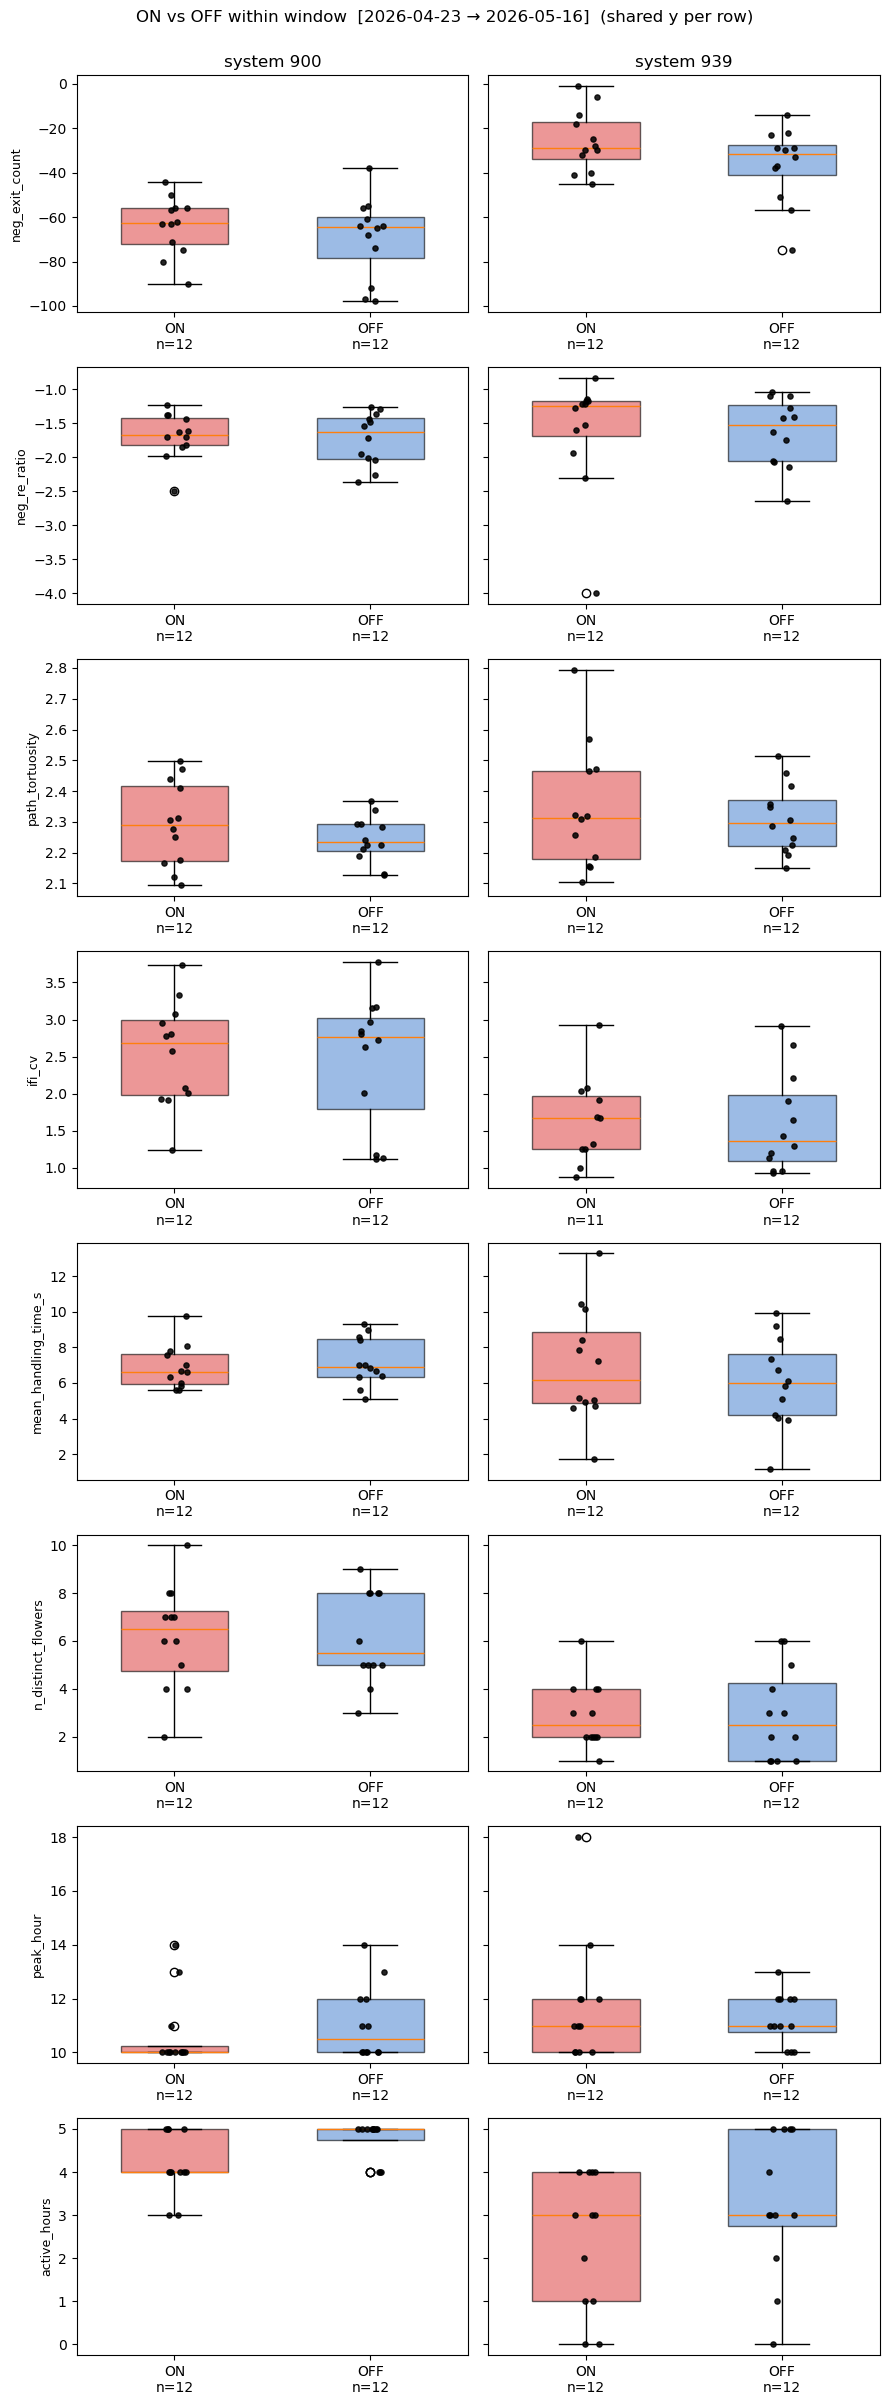

In [16]:
# ─── boxplot grid: indicator × system, ON vs OFF (shared y per row) ───
systems = sorted(sub["system_id"].unique())
fig, axes = plt.subplots(len(INDICATORS), len(systems),
                         figsize=(4.5 * len(systems), 3.0 * len(INDICATORS)),
                         sharey="row", squeeze=False)

ORDER  = ["ON", "OFF"]
COLOUR = {"ON": "#E05252", "OFF": "#5B8FD4"}

for row, col in enumerate(INDICATORS):
    for j, sid in enumerate(systems):
        ax = axes[row][j]
        if col not in sub.columns:
            ax.set_axis_off(); continue
        data = [sub[(sub.system_id == sid) & (sub.condition == c)][col].dropna().values
                for c in ORDER]
        labels = [f"{c}\nn={len(d)}" for c, d in zip(ORDER, data)]
        bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.55)
        for patch, c in zip(bp["boxes"], ORDER):
            patch.set_facecolor(COLOUR[c]); patch.set_alpha(0.6)
        for k, vals in enumerate(data):
            if len(vals):
                ax.scatter(np.full(len(vals), k + 1) + np.random.uniform(-0.07, 0.07, len(vals)),
                           vals, color="black", s=14, alpha=0.85, zorder=3)
        if row == 0: ax.set_title(f"system {sid}")
        if j == 0:   ax.set_ylabel(col, fontsize=9)

fig.suptitle(f"ON vs OFF within window  [{DATE_START or 'min'} → {DATE_END or 'max'}]  "
             "(shared y per row)", y=1.0)
plt.tight_layout(); plt.show()


## Reading the table

Each indicator-system pair has two parallel sets of statistics: `_w` (the user-
chosen window) and `_f` (the full experimental window). To check whether a
finding is sensitive to the date window:

1. Compare `r_w` and `r_f`. A negligible `delta_r` (say $|\Delta r| < 0.05$)
   means trimming the window made no difference and the result is robust.
   A large `delta_r` means the result is window-dependent — at minimum a
   reason to flag it as fragile, and at maximum a sign that something inside
   the trimmed-off period is doing the work.

2. Compare `sig_w` and `sig_f`. If `sig_f` is `*` or better but `sig_w` is
   `ns`, the effect on the full window came largely from the trimmed-off
   period.

3. Sample sizes (`n_ON_w`, `n_OFF_w`, `n_ON_f`, `n_OFF_f`) are reported
   explicitly so you can see how many days each comparison actually used.

The default window in the config cell trims everything from 17~May onward,
which removes the last ON block (overlapping with the late-May heatwave).
The intended use is: run, look at `active_hours` on system~939, and read
`r_w`, `r_f`, and `delta_r` directly.


## Spotlight — system 900 `peak_hour`, window vs full (paste-ready)

Focuses on the single most-substantive sys 900 finding (medium effect size, marginal $p$ on the full window) and prints all the numbers needed for the report in one block, plus a side-by-side boxplot.

=== system 900 — peak_hour : window vs full ===

Window  2026-04-23 -> 2026-05-16
  ON   n=12  median= 10.0h  IQR=10.0-10.2
  OFF  n=12  median= 10.5h  IQR=10.0-12.0
  MWU  U=56.0  p=0.356 (ns)  rank-biserial r=+0.222 (small)

Full    2026-04-13 -> 2026-05-28
  ON   n=18  median= 10.0h  IQR=10.0-12.5
  OFF  n=17  median= 10.0h  IQR=10.0-12.0
  MWU  U=152.5  p=0.987 (ns)  rank-biserial r=+0.003 (neg)

Comparison:
  delta_r (window - full)     = +0.219
  delta_median ON (window-full) = +0.00 hours
  delta_median OFF (window-full) = +0.50 hours

--- paste-ready for main.tex (sys 900 peak_hour) ---
On system 900, the median peak foraging hour was 10:00 on ON days vs 10:00 on OFF days across the full experimental window (n = 18 vs 17 day-rows, U = 152.5, p = 0.987, rank-biserial r = +0.00, neg effect, ns). Restricting the analysis to 2026-04-23 - 2026-05-16 (n = 12 vs 12, removing the late-May ON block) preserved the directional pattern (median 10:00 vs 10:00, U = 56.0, p = 0.356, r = +0.22

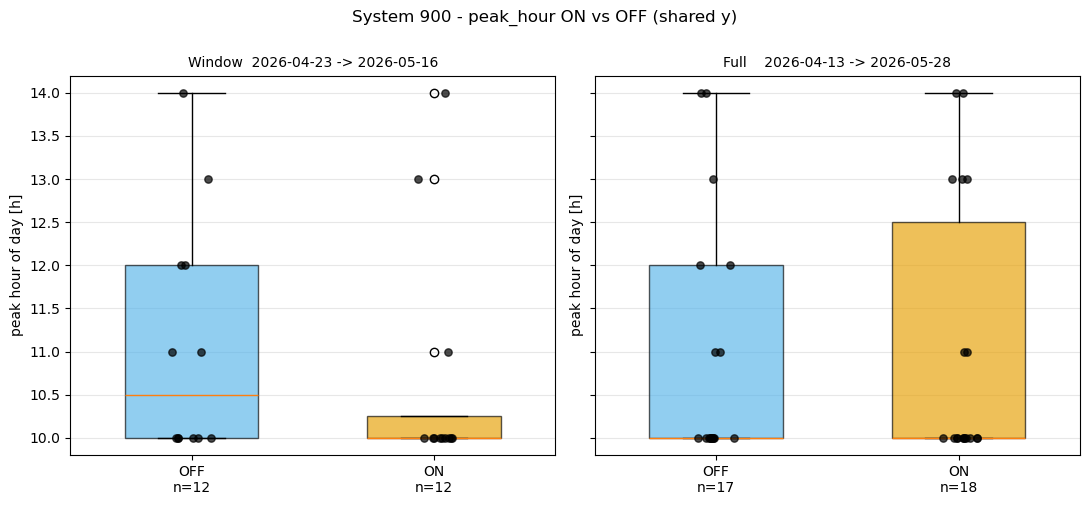

In [17]:
# ─── Spotlight: system 900 peak_hour — window vs full ───
SPOT_SID = 900
SPOT_IND = "peak_hour"

ph_w_on  = sub[(sub.system_id == SPOT_SID) & (sub.condition == "ON")][SPOT_IND].dropna().values
ph_w_off = sub[(sub.system_id == SPOT_SID) & (sub.condition == "OFF")][SPOT_IND].dropna().values
ph_f_on  = analysis[(analysis.system_id == SPOT_SID) & (analysis.condition == "ON")][SPOT_IND].dropna().values
ph_f_off = analysis[(analysis.system_id == SPOT_SID) & (analysis.condition == "OFF")][SPOT_IND].dropna().values

Uw, pw, rw, _, _ = mwu(ph_w_on, ph_w_off)
Uf, pf, rf, _, _ = mwu(ph_f_on, ph_f_off)

def _quartiles(a):
    return float(np.percentile(a, 25)), float(np.median(a)), float(np.percentile(a, 75))

print(f"=== system {SPOT_SID} — peak_hour : window vs full ===\n")
for label, on, off, U, p, r in [
    (f"Window  {DATE_START or 'min'} -> {DATE_END or 'max'}",
        ph_w_on, ph_w_off, Uw, pw, rw),
    (f"Full    {analysis['date_ts'].min().date()} -> {analysis['date_ts'].max().date()}",
        ph_f_on, ph_f_off, Uf, pf, rf),
]:
    q25_on,  m_on,  q75_on  = _quartiles(on)
    q25_off, m_off, q75_off = _quartiles(off)
    print(label)
    print(f"  ON   n={len(on):2d}  median={m_on:5.1f}h  IQR={q25_on:.1f}-{q75_on:.1f}")
    print(f"  OFF  n={len(off):2d}  median={m_off:5.1f}h  IQR={q25_off:.1f}-{q75_off:.1f}")
    print(f"  MWU  U={U:.1f}  p={p:.3f} ({sig_label(p)})  rank-biserial r={r:+.3f} ({effect_label(r)})")
    print()

print("Comparison:")
print(f"  delta_r (window - full)     = {rw-rf:+.3f}")
print(f"  delta_median ON (window-full) = {np.median(ph_w_on)  - np.median(ph_f_on):+.2f} hours")
print(f"  delta_median OFF (window-full) = {np.median(ph_w_off) - np.median(ph_f_off):+.2f} hours")

# ── Paste-ready sentence for the report ──
print("\n--- paste-ready for main.tex (sys 900 peak_hour) ---")
print(
    f"On system 900, the median peak foraging hour was "
    f"{int(np.median(ph_f_on)):d}:00 on ON days vs {int(np.median(ph_f_off)):d}:00 on OFF days "
    f"across the full experimental window "
    f"(n = {len(ph_f_on)} vs {len(ph_f_off)} day-rows, U = {Uf:.1f}, p = {pf:.3f}, "
    f"rank-biserial r = {rf:+.2f}, {effect_label(rf)} effect, {sig_label(pf)}). "
    f"Restricting the analysis to {DATE_START} - {DATE_END} "
    f"(n = {len(ph_w_on)} vs {len(ph_w_off)}, removing the late-May ON block) "
    f"preserved the directional pattern (median {int(np.median(ph_w_on)):d}:00 vs {int(np.median(ph_w_off)):d}:00, "
    f"U = {Uw:.1f}, p = {pw:.3f}, r = {rw:+.2f}). "
    f"The effect size was robust to the date-window choice (Delta r = {rw-rf:+.2f})."
)

# ── Focused boxplot ──
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
COLOUR = {"OFF": "#56B4E9", "ON": "#E69F00"}   # colourblind-safe (Wong)
for ax, (data, title) in zip(
    axes,
    [((ph_w_off, ph_w_on),
      f"Window  {DATE_START or 'min'} -> {DATE_END or 'max'}"),
     ((ph_f_off, ph_f_on),
      f"Full    {analysis['date_ts'].min().date()} -> {analysis['date_ts'].max().date()}")]):
    off, on = data
    bp = ax.boxplot([off, on],
                    tick_labels=[f"OFF\nn={len(off)}", f"ON\nn={len(on)}"],
                    patch_artist=True, widths=0.55)
    for patch, c in zip(bp["boxes"], [COLOUR["OFF"], COLOUR["ON"]]):
        patch.set_facecolor(c); patch.set_alpha(0.65)
    for k, vals in enumerate([off, on]):
        ax.scatter(np.full(len(vals), k + 1) + np.random.uniform(-0.08, 0.08, len(vals)),
                   vals, color="black", s=28, alpha=0.7, zorder=3)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("peak hour of day [h]")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle(f"System {SPOT_SID} - peak_hour ON vs OFF (shared y)", y=1.0, fontsize=12)
plt.tight_layout(); plt.show()


## Truncated view — system 900 only (one mini-table per indicator)

Compact summary for the reliable system. Each indicator gets three rows
(`windowed`, `full`, `delta = windowed − full`) and the columns are
`med_ON`, `med_OFF`, `U`, `p`, `r`, `sig`. Useful as paste-ready snippets
for the report (one block per indicator).

In [18]:
# ── Truncated sys-900 print: 3 rows (windowed / full / delta) per indicator ──
SPOT_SID = 900

print(f"=== sys {SPOT_SID} — windowed vs full vs delta (per indicator) ===\n")
for ind in INDICATORS:
    rows_sub = res[(res["system"] == SPOT_SID) & (res["indicator"] == ind)]
    if rows_sub.empty:
        continue
    row = rows_sub.iloc[0]
    if not pd.notna(row["U_w"]) or not pd.notna(row["U_f"]):
        print(f"--- {ind} ---  (insufficient data)\n")
        continue

    table = pd.DataFrame(
        {
            "med_ON":  [row["med_ON_w"],
                        row["med_ON_f"],
                        row["med_ON_w"]  - row["med_ON_f"]],
            "med_OFF": [row["med_OFF_w"],
                        row["med_OFF_f"],
                        row["med_OFF_w"] - row["med_OFF_f"]],
            "U":       [row["U_w"],   row["U_f"],   row["U_w"]   - row["U_f"]],
            "p":       [row["p_w"],   row["p_f"],   row["p_w"]   - row["p_f"]],
            "r":       [row["r_w"],   row["r_f"],   row["r_w"]   - row["r_f"]],
            "sig":     [row["sig_w"], row["sig_f"], ""],
        },
        index=["windowed", "full", "delta"],
    )
    print(f"--- {ind} ---")
    print(table.round(3).to_string())
    print()


=== sys 900 — windowed vs full vs delta (per indicator) ===

--- neg_exit_count ---
          med_ON  med_OFF      U      p      r sig
windowed   -62.5    -64.5   57.0  0.386  0.208  ns
full       -59.5    -61.0  152.0  0.974  0.007  ns
delta       -3.0     -3.5  -95.0 -0.588  0.201    

--- neg_re_ratio ---
          med_ON  med_OFF      U      p      r sig
windowed  -1.666   -1.626   67.0  0.773  0.069  ns
full      -1.624   -1.580  132.0  0.488  0.137  ns
delta     -0.042   -0.046  -65.0  0.285 -0.068    

--- path_tortuosity ---
          med_ON  med_OFF      U      p      r sig
windowed   2.291    2.234   58.0  0.419  0.194  ns
full       2.291    2.293  149.0  0.895  0.026  ns
delta      0.000   -0.059  -91.0 -0.476  0.168    

--- ifi_cv ---
          med_ON  med_OFF      U      p      r sig
windowed   2.682    2.761   72.0  1.000  0.000  ns
full       2.175    2.010  138.0  0.621  0.098  ns
delta      0.507    0.751  -66.0  0.379 -0.098    

--- mean_handling_time_s ---
       